# 05. 성향점수
- **처치를 받을 조건부 확률**
- 성향점수를 활용하면 직교화처럼 잔차를 생성하는 대신, 처치 배정 메커니즘을 모델링하고, 모델 예측을 사용하여 데이터를 재조정 (Reweight)
- 이진이나 이산형 처치가 있을 때 적합한 메커니즘

<br>



In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import graphviz as gr
from matplotlib import style
import seaborn as sns
from matplotlib import pyplot as plt
style.use("ggplot")
import statsmodels.formula.api as smf
import matplotlib
from cycler import cycler

color=['0.2', '0.6', '1.0']
default_cycler = (cycler(color=color))
linestyle=['-', '--', ':', '-.']
marker=['o', 'v', 'd', 'p']


plt.rc('axes', prop_cycle=default_cycler)

<br>

<hr>

<br>

## 05.01. 관리자 교육의 효과 예시

> 회사에서는 유능한 개인 기여자 (Individual Contributiors, IC)들이 관리직 경로로 전환하는 것이 일반적
>
> 하지만 관리직은 IC로서의 재능과는 다른 기술이 필요할 때가 많아서 이러한 전환은 쉽지 않음
>
> 새로운 관리자뿐만 아니라 그들이 관리하는 팀원들에게도 큰 부담을 줄 수 있음
>
> **회사는 교육의 효과를 측정하려고 관리자들을 무작위로 프로그램에 참여**
>
> **교육 프로그램에 배정된 일부 관리자는 참석하지 않았으며, 참석 대상이 아닌 관리자 중에서도 교육을 받은 일부가 존재**

<br>

- **불응 : 실험 대상이 의도한 처치를 받지 못하는 것(Non-Compliance)**


<br>

#### 데이터 로드
- `intervention` : 처치변수
- `engagement_score` : 관리자와 일하는 직원의 표준화된 평균 참여점수 (결과변수)
- `department_id` : 부서 고유 식별자
- `tenure` : 관리자의 근속 기간 (관리자가 아닌 직원으로써의 근속 기간)
- `n_of_reports` : 관리자가 담당한 보고서 수
- `gender` : 관리자 성별에 대한 범주형 변수
- `role` : 회사 내 직군
- `department_size` : 부서의 직원 수
- `department_score` : 같은 부서의 평균 참여점수
- `last_engagement_score` : 이전 참여도 조사에서 해당 관리자의 평균 참여점수


In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/management_training.csv")
df.head()

,departament_id,intervention,engagement_score,tenure,n_of_reports,gender,role,last_engagement_score,department_score,department_size
0,76,1,0.277359,6,4,2,4,0.614261,0.224077,843
1,76,1,-0.449646,4,8,2,4,0.069636,0.224077,843
2,76,1,0.769703,6,4,2,4,0.866918,0.224077,843
3,76,1,-0.121763,6,4,2,4,0.029071,0.224077,843
4,76,1,1.526147,6,4,1,4,0.589857,0.224077,843


<br>

<hr>

<br>

## 05.02. 회귀분석과 보정
- 회귀분석을 사용한 교란요인 보정
- 성향점수 가중치 추정값이 회귀 추정값과 같은지를 확인

In [5]:
import statsmodels.formula.api as smf

- 단순 처치 실험군과 대조군 비교

In [6]:
smf.ols("engagement_score ~ intervention", data=df).fit().summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,-0.2347,0.014,-16.619,0.000,-0.262,-0.207
intervention,0.4346,0.019,22.616,0.000,0.397,0.472


<br>

- **하지만, 처치가 완전히 무작위로 배정되지 않았으므로 해당 결과는 편향되었을 것**

    $\rightarrow$ 데이터가 있는 공변량을 보정

    (모든 교란 요인과 절편을 위한 상수 열을 포함)

$$engagment_i = \tau T_i + \theta X_i + e_i$$

<br>

- **효과 추정값이 이전의 모델보다 작아짐 $\rightarrow$ 긍정 편향** 

    $\rightarrow$ **이미 직원 참여도가 높은 관리자가, 교육 프로그램에 더 많이 참여 했을 가능성이 높다는 의미**

    (이전 모델의 효과에, 원래 참여도가 높았던 성향이 섞여 있던 것)

In [8]:
model = smf.ols("""engagement_score ~ intervention + tenure + last_engagement_score + department_score + n_of_reports + C(gender) + C(role)""", data=df).fit()

print("ATE:", model.params["intervention"])
print("95% CI:", model.conf_int().loc["intervention", :].values.T)

ATE: 0.26779085766768695
95% CI: [0.23357751 0.30200421]



<br>

<hr>

<br>

## 05.03. 성향점수
- **성향점수 가중치는 성향점수 (Propensity Score)라는 개념을 중심으로 이루어지며, 이는 교란 요인 $X$를 직접 통제할 필요 없이 조건부 독립성 $(Y_1, Y_0) \perp T | X$를 만족할 수 있음**
- **교란 요인을 통제하는 대신  $E[T|X]$를 추정하는 균형점수 (Balancing Score)를 통제해도 충분**
    - **이 균형점수는 종종 처치의 조건부 확률 ($P(T|X)$)이나 성향점수 ($e(x)$)라고 부름**

<br>

- **성향점수는 차원 축소 기법으로 볼 수 있으며, 고차원일 수 있는 $X$를 조건부로 설정하는 대신, 성향점수를 조건부로 두고 $X$로 유입되는 백도어를 차단할 수 있으며**

    수식으로는 $(Y_1, Y_0) \perp T|P(x)$로 표현 가능

<br>

- 성향 점수는 처치를 받을 조건부 확률이기에, $X$를 $T$로 변환하는 일종의 함수라고 생각 가능
    
    $\rightarrow$ **성향 점수는 공변량 $X$와 처치$T$ 중간에 존재**

    $\rightarrow$ **$e(X)$를 통제하면 곧 $X$를 직접 통제할 때와 동일한 효과가 나타남**

    - 예) 실험군과 대조군에서 각각 한 명씩 두 사람을 뽑되, 처치를 받을 확률이 동일하다면, 두 그룹은 비교가능
        - 한 명잋 처치를 받고, 한 명이 처치를 받지 않은 유일한 이유는 순전히 우연에 의한 것이기 때문

    $\rightarrow$ **성향점수가 동일한 상황에서 처치는 사실상 무작위 배정된 것과 동일**

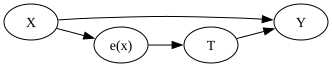

In [9]:
g = gr.Digraph(graph_attr={"rankdir":"LR"})
g.edge("T", "Y")
g.edge("X", "Y")
g.edge("X", "e(x)")
g.edge("e(x)", "T")

g


<br>

### 01. 성향점수 추정
- **실제 성향점수 $e(x)$는 알 수 없는 것**
    - 현실에서 처치 배정 메커니즘은 대부분 알 수 없으며, 실제 성향점수를 추정값으로 대체해야함

<br>

- 예시에서 처치는 이진 처치이므로 $e(x)$를 추정할 때 로지스틱 회귀 사용 가능

In [11]:
ps_model = smf.logit("""intervention ~ tenure + last_engagement_score + department_score + C(n_of_reports) + C(gender) + C(role)""", data=df).fit(disp=0)

In [12]:
data_ps = df.assign(
    propensity_score = ps_model.predict(df),
)

data_ps[["intervention", "engagement_score", "propensity_score"]].head()

,intervention,engagement_score,propensity_score
0,1,0.277359,0.596106
1,1,-0.449646,0.391138
2,1,0.769703,0.602578
3,1,-0.121763,0.580990
4,1,1.526147,0.619976


<br>

#### 성향점수와 머신러닝
- 머신러닝을 사용하여 성향점수를 추정할 때, 두 가지 주의점
    - 머신러닝을 모델에서 보정된 확률 (Calibrated Probability)예측값이 나오는지 확인해야함
    - 과적합에서 오는 편향을 피하려면 OOF 방식의 예측을 활용해야함

<br>

### 02. 성향점수와 직교화

- FWL 정리에 따르면 선형회귀도 성향점수 추정과 매우 비슷하며, 편향 제거 단계에서 $E[T|X]$를 추정

    즉, OLS는 성향점수 추정과 매우 비슷한 처치 배정 메커니즘을 모델링

    $\rightarrow$ **선형회귀에서 교란 요인 $X$를 보정하기 위해, 성향점수 $\hat{e}(x)$를 사용할 수 있음을 의미**

<br>

- **이 접근법으로 얻은 ATE 추정값은 $X$를 포함한 모델의 추정값과 매우 유사**

    - 차이점은 OLS는 선형회귀분석을 사용하여 $T$를 모델링
    - 성향점수 추정값은 로지스틱 회귀분석을 사용하여 모델링

In [14]:
model = smf.ols("engagement_score ~ intervention + propensity_score", data=data_ps).fit()
model.params["intervention"]

0.263312674902774

<br>

### 03. 성향점수 매칭
- **성향점수를 통제하는 또 다른 접근 방식은 매칭 추정량 (Matching Estimator)**
    
    **관측 가능한 특징이 비슷한 실험 대상의 짝을 찾아 실험군과 대조군을 비교**

<br>

#### 기본 아이디어

- 실험군의 특정 관측값과 성향 점수가 비슷한 관측값을, 대조군으로부터 대체
- 대조군의 특정 관측값과 성향 점수가 비슷한 관측값을, 실험군으로부터 대체

    $\rightarrow$ 모든 관측값에 대해 '처치를 받은 경우' $Y_1$ 와 '처치를 받지 않은 경우' $Y_0$의 값을 다 얻을 수 있음

<br>

- **성향점수가 비슷하다는 것은 배경 조건이 거의 비슷하다는 것을 의미 $\rightarrow$ 배경조건이 똑같은 두 관측값의 결과 차이는 오직 '처치' 때문임을 말할 수 있음**


<br>

#### KNN 알고리즘 적용
1. 성향점수를 특성으로 사용하여 실험군에 KNN 모델을 적합시키고, 대조군의 $Y_1$을 대체하는 데 사용
2. 대조군에 KNN 모델을 적합시키고 실험군의 $Y_0$을 대체

$\rightarrow$ **두 경우 모두 대체된 값은 성향점수에 기반하여 매칭된 실험 대상의 결과**

In [15]:
from sklearn.neighbors import KNeighborsRegressor

In [16]:
T = "intervention"
X = "propensity_score"
Y = "engagement_score"

In [17]:
treated = data_ps.query(f"{T}==1")
untreated = data_ps.query(f"{T}==0")

mt0 = KNeighborsRegressor(n_neighbors=1).fit(untreated[[X]], untreated[Y])

mt1 = KNeighborsRegressor(n_neighbors=1).fit(treated[[X]], treated[Y])

In [24]:
predicted = pd.concat([
    # find matches for the treated looking at the untreated knn model
    treated.assign(match=mt0.predict(treated[[X]])),
    
    # find matches for the untreated looking at the treated knn model
    untreated.assign(match=mt1.predict(untreated[[X]]))
])

predicted.head()

,departament_id,intervention,engagement_score,tenure,n_of_reports,gender,role,last_engagement_score,department_score,department_size,propensity_score,match
0,76,1,0.277359,6,4,2,4,0.614261,0.224077,843,0.596106,0.557680
1,76,1,-0.449646,4,8,2,4,0.069636,0.224077,843,0.391138,-0.952622
2,76,1,0.769703,6,4,2,4,0.866918,0.224077,843,0.602578,-0.618381
3,76,1,-0.121763,6,4,2,4,0.029071,0.224077,843,0.580990,-1.404962
4,76,1,1.526147,6,4,1,4,0.589857,0.224077,843,0.619976,0.000354


<br>

- 각 실험 대상에 짝이 지어졌다면, ATE를 다음과 같이 추정 가능

$$\hat{ATE} = \frac{1}{N}\{(Y_i - Y_{jm}(i)) T_i + (Y_{jm}(i) - Y_i)(1-T_i)\}$$

In [25]:
np.mean((predicted[Y] - predicted["match"])*predicted[T] + (predicted["match"] - predicted[Y])*(1-predicted[T]))

0.28777443474045966

<br>

#### 매칭 추정량의 편향
- 성향점수 추정값인 $\hat{P}(T|X)$를 구성하는 데 사용한 원래 특성 $X$에 성향점수를 바로 매칭 가능
- 하지만 매칭 추정량은 편향될 수 있으며, $X$의 차원이 클수록 편향이 증가
- 차원이 높아질수록 데이터가 희소해지고, 매칭의 정확성은 더 떨어짐
- 대조군과 실험군에 대한 기대 결과 함수를 각각 $\mu_0(X)$와 $\mu_1(X)$라고 했을 때, 편향은 기대 결과와 매칭 결과 사이의 불일치 (Discrepancy)

    즉, 실험군에 대한 편향은 $\mu_0(X_i) - \mu_0(X_{jm})$, 대조군의 편향은 $\mu_1(X_{jm}) - \mu_1(X_i)$

    여기서 $X_{jm}$은 짝지어진 대상의 공변량

- 즉 편향을 피하고 매칭을 사용하기 위해서는 아래와 같은 편향 보정식을 적용해야 함


$$
\hat{ATE} = \frac{1}{N} \sum \{ (Y_i - Y_{jm} (i) - (\hat{\mu_0}(X_i) - \hat{\mu_0} (X_{jm}))) T_i + (Y_{jm} (i) - Y_i - (\mu_1 (X_{jm}) - \mu_1 (X_i)))(1-T_i)\}

$$

<br>

- 매칭 추정량은 편향될 가능성이 있고, 분산을 추정하기 여려우며,

    대체 알고리즘 (KNN 등)의 효율성에 크게 의존
    - KNN은 $X$가 고차원인 경우, 대체로 효율이 크게 떨어짐

<br>

### 04. 역확률 가중치
- **성향점수 매칭 (PSM)이외에도 성향점수를 활용하는 역확률 가중치 (Inver Propensity Weighting, IPW)도 널리 사용**
- **처치의 역확률 (Inverse Prob)에 따라 데이터의 가중치를 재조정하여, 해당 데이터에서 처치가 무작위 배정된 것 처럼 보이게 할 수 있음**

    $\rightarrow$ **표본에 $1/P(T=t|X)$가중치를 부여하여, 모든 실험 대상이 처치 $t$를 받았을 경우와 비슷한 유사 모집단 (Pseudo Population)을 생성**

$$E[Y_t] = E[\frac{\mathbb{1}(T=t)Y}{P(T=t|X)}]$$


<br>

- 예) 모든 관리자가 교육받았을 때의 평균 참여도 ($Y_1$)의 기댓값을 알고 싶을 때
    
    **실험군을 처치 받을 확률의 역수로 조정 $\rightarrow$ 처치 받을 확률이 매우 낮은데도, 처치 받은 대상에게 높은 가중치를 부여**

    $\rightarrow$ **실질적으로 드문 처치 사례에 더 많은 가중치**

    $\rightarrow$ **실험군에 속한 대상이 처치 받을 확률이 낮다면, 해당 대상은 대조군과 매우 유사하게 보이게 됨**

    $\rightarrow$ **대조군이 처치 받았을 때 어떤일이 일어날지 $Y_1|T=0$에 대한 매우 유용한 정보를 제공**

    (마찬가지로 대조군에 속한 대상이 실험군과 매우 유사하다면 $Y_0 | T= 1$의 좋은 추정값이 될 수 있음)

<br>


- 성향점수로 평균 잠재적 결과를 알아낼 수 있다면, ATE는

$$
ATE = E[\frac{\mathbb{1}(T=1)Y}{P(T=1|X)}] - E[\frac{\mathbb{1}(T=0)Y}{P(T=0|X)}]
$$

$$
\text{혹은}
$$

$$
ATE = E[\frac{T-e(x)}{e(x)(1-e(x))}]
$$

In [36]:
g_data = (
    data_ps
    .assign(
        weight = data_ps["intervention"]/data_ps["propensity_score"] + (1-data_ps["intervention"])/(1-data_ps["propensity_score"]),
        propensity_score=data_ps["propensity_score"].round(2)
    )
    .groupby(["propensity_score", "intervention"])
    [["weight", "engagement_score"]]
    .mean()
    .reset_index()
)

g_data.head()

,propensity_score,intervention,weight,engagement_score
0,0.12,0,1.141123,-0.692612
1,0.12,1,8.632830,0.302186
2,0.13,0,1.143852,-0.203823
3,0.13,1,7.653620,-0.293712
4,0.14,0,1.167771,-0.771809


<br>

- 공변량 $X$를 보정하지 않고 단순히 얻은 결과보다 ATE가 더 작음
- 역확률 가중치를 바탕으로 얻은 결과는 OLS결과와 매우 비슷함

In [ ]:
weight_t = 1/data_ps.query("intervention==1")["propensity_score"]
weight_nt = 1/(1-data_ps.query("intervention==0")["propensity_score"])
t1 = data_ps.query("intervention==1")["engagement_score"] 
t0 = data_ps.query("intervention==0")["engagement_score"] 

y1 = sum(t1*weight_t)/len(data_ps)
y0 = sum(t0*weight_nt)/len(data_ps)

print("E[Y1]:", y1)
print("E[Y0]:", y0)
print("ATE", y1 - y0)

E[Y1]: 0.11656317232946992
E[Y0]: -0.14941553647814657
ATE 0.2659787088076165


<br>

- 각 점의 크기가 가중치인 관리자 교육 훈련 데이터 그래프
    - $\hat{e}(x)$가 낮을 때, 교육 받은 관리자 ($T=1$)의 높은 가중치
        - 교육받지 않은 것 처럼 보이는, 교육 받은 관리자에게 높은 중요도를 부여
    - $\hat{e}(x)$가 높거나, $\hat{P}(T=0 | X)$가 낮을 떄 교육받지 않은 관리자는 높은 가중치를 받음

    $\rightarrow$ **교육받은 관리자 그룹 (실험군) 처럼 보이는 대조군이 매우 중요**

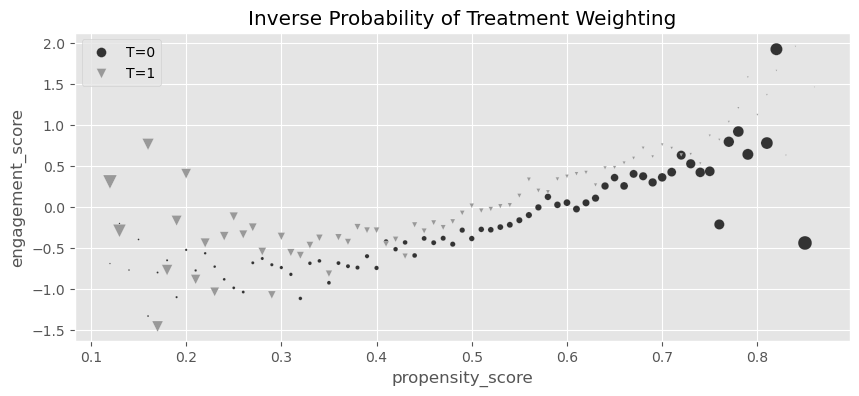

In [34]:
plt.figure(figsize=(10,4))

for t in [0, 1]:
    sns.scatterplot(data=g_data.query(f"intervention=={t}"), y="engagement_score", x="propensity_score", size="weight",
                    sizes=(1,100), color=color[t], legend=None, label=f"T={t}", marker=marker[t])

plt.title("Inverse Probability of Treatment Weighting")
plt.legend()
plt.show()

<br>

#### 회귀분석과 역확률 가중치
- 회귀분석에서는 다음과 같은 방식으로 처치효과를 추정

$$
\tau_{ols} = \frac{E[Y(T-E[T|X])]}{E[Var(T|X)]} = E[\frac{Y(T-E[T|X])}{Var(T|X)} \times \frac{Var(T|X)}{E[Var(T|X)]}]
$$

- 역확률 가중치는 다음과 같은 방식으로 처치효과를 추정

$$
\tau_{ipw} = E[\frac{Y(T-E[T|X])}{Var(T|X)}]
$$

<br>

- **IPW는 각 표본에 1을 가중치로 부여하지만, 회귀분석은 처치의 조건부 분산으로 그룹 효과에 가중치를 부여함**
    - 처치의 변동이 큰 부분에 회귀분석이 더 큰 가중치를 부여

<br>


### 05. 역확률 가중치의 분산
- **IPW추정값의 신뢰구간을 얻는 가장 간단한 방법은 부트스트랩**
    - 데이터를 반복적으로 복원추출하여 여러 IPW 추정값을 구할 수 있으며, 이 추정값의 분위수를 계산하여 95% 신뢰구간 계산 가능

<br>

- IPW 추정 함수 정의


In [40]:
from sklearn.linear_model import LogisticRegression
from patsy import dmatrix

In [46]:
def est_ate_with_ps(df, ps_formula, T, Y):
    
    X = dmatrix(ps_formula, df)
    ps_model = LogisticRegression(max_iter=1000).fit(X, df[T])
    ps = ps_model.predict_proba(X)[:, 1]
    
    return np.mean((df[T]-ps) / (ps*(1-ps)) * df[Y]) 

<br>

#### 부트스트랩 과정 적용
- 연산속도를 위한 리샘플링 실행

1. 부트스트랩 표본 추출 `.sample(frac=1, replace=True)` 
2. 부트스트랩 표본을 함수에 전달

In [55]:
from joblib import Parallel, delayed
from toolz import partial

In [49]:
def bootstrap(data, est_fn, rounds=200, seed=123, pcts=[2.5, 97.5]):
    np.random.seed(seed)
    
    stats = Parallel(n_jobs=4)(
        delayed(est_fn)(data.sample(frac=1, replace=True)) # 부트스트랩 표본
        for _ in range(rounds)
    )
    
    return np.percentile(stats, pcts)

- 부트스트랩 표본마다 한 번씩 IPW 추정 함수를 실행하여 배열을 생성
- 생성 이후 95% 신뢰구간 계산

<br>

#### `partial` 함수
- `partial` 함수는 함수와 해당 함수의 일부 인수들을 받아서, 이 인수들이 미리 적용된 새로운 함수를 생성함
- `partial` 함수를 사용하여 `est_ate_with_ps` 함수를 호출하고, 그 안의 수식, 처치, 결과 인수를 부분적으로 적용

In [62]:
formula = """tenure + last_engagement_score + department_score + C(n_of_reports) + C(gender) + C(role)"""
T = "intervention"
Y = "engagement_score"

In [63]:
print(f"ATE: {est_ate_with_ps(df, formula, T, Y)}")

est_fn = partial(est_ate_with_ps, ps_formula=formula, T=T, Y=Y)
print(f"95% C.I.: ", bootstrap(df, est_fn))

ATE: 0.2663477715008711
95% C.I.:  [0.22654885 0.30087917]


<br>

- 큰 가중치가 적용되면 성향점수 추정량의 분산이 크게 증가함

    **큰 가중치를 가진다는 것은 몇몇 실험 대상이 최종 추정값에 큰 영향을 미친다는 의미**

    **즉, 최종 추정값에 큰 영향을 주는 소수의 대상들이 바로 분산 증가의 원인**

- **성향점수가 높은 부분에 대조군의 실험 대상이 적거나, 성향점수가 낮은 부분에 실험군의 대상이 적은 경우, 큰 가중치를 가짐**

    **이는 반사실적 결과  $Y_0 | T=1$과 $Y_1 | T = 0$을 추정할 대상이 적어지므로, 결과에 잡음이 많을 수 있음**

<br>

#### 인과적 콘텍스트 밴딧
- 콘텍스트 밴딧(Context Bandit)은 강화학습의 한 종류로, 선택적 의사결정 정책을 학습하는 것이 목표
- 컨텍스트 밴딧은 샘플링과 추정이라는 두 가지 요소로 이루어짐

1. 샘플링 요소는 아직 탐색되지 않은 영역에서 데이터 수집과 최적의 처치 배정의 균형을 맞춤
2. 추정 요소는 사용 가능한 데이터로 최적의 처치를 찾으려고 탐색

<br>

- 추정 구성 요소는 최적의 처치 배정 메커니즘을 학습하려는 인과추론 문제로 구성 가능

    **여기서 최선은 최적화하려는 결과 $Y$의 기댓값으로 정의**
- **알고리즘의 목표가 최적의 방식으로 처치를 배정하는 것이므로, 알고리즘이 수집하는 데이터는 무작위가 아닌 교란된 데이터**

    $\rightarrow$ 컨텍스트 밴딧에 인과적 접근 방식을 사용하면 개선 효과를 얻을 수 있음

<br>

- 의사결정 과정이 확률적이라면 각 처치를 배정할 확률을 얻을 수 있으며, 이는 바로 성향점수 $e(x)$

    $\rightarrow$ 이 성향점수를 사용하여 이미 처치가 선택되고 관측된 결과가 있는 과거 데이터를 재조정할 수 있음

    $\rightarrow$ 재조정된 데이터는 교란 요인이 없어야 하며, 그에 따라 최적의 처치를 학습하기 훨씬 쉬워짐

<br>

<br>

### 06. 안정된 성향점수 가중치
- 머신러닝 관점에서, IPW를 중요도 샘플링 (Importance Sampling)의 응용으로 접근 가능

<br>

1. **IPW는 편향된 샘플을 '목표 분포'로 강제로 돌려좋는 중요도 샘플링의 일종**
- **목표분포 ($p(x)$) : 원래 관심을 가지고 있는 확률 분포**
    - 현실에서는 이 목표분포에서 데이터를 직접 샘플링하기 어렵거나 불가능
- **중요도 샘플링 : 목표 분포에서 직접 샘플링을 하지 못하니, 대안 분포 ($q(x)$)에서 데이터를 뽑은 뒤, 가중치를 곱해서 목표 분포의 결과인 것 처럼 보정**

    $\rightarrow$ **IPW는 성향점수의 역수를 가중치로 곱해서, 마치 목표 분포에서 얻은 데이터인 것 처럼 바꿔버리는 것**

2. **가중치를 곱하면 $X$와 $T$의 관계가 끊어져서 꺠끗한 분석이 가능**
3. **하지만 확률이 너무 낮은 샘플 때문에 수치가 튈 수 있으므로(불안정성), 이를 잡아주는 안정화 작업이 필요**

<br>

#### 실험군과 대조군의 가중치 합이 원래 표본 크기에 얼마나 가까운지 확인

In [64]:
print("원본 데이터의 크기", data_ps.shape[0])
print("처치군의 가중치 합", sum(weight_t))
print("대조군의  가중치 합", sum(weight_nt))

원본 데이터의 크기 10391
처치군의 가중치 합 10435.089079197896
대조군의  가중치 합 10354.298899788295


<br>

- **처치확률이 매우 낮다면 $P(T|X)$의 값이 매우 작아져 계산상의 문제가 발생 가능**

    (분자가 항상 1이기 때문에, 성향점수가 너무 낮다면 가중치가 폭증 (=분산이 폭증))

    $\rightarrow$ **이를 해결하기 위해 처치의 주변확률인 $P(T=t)$를 분자에 사용하여 가중치를 안정화**

$$
w = \frac{P(T=t)}{P(T=t|X)}
$$

- **이 가중치를 사용하면 작은 분모가 작은 분자와 균형을 이루므로, 확률이 낮은 처치에 큰 가중치가 적용되지 않음**

- 안정된 가중치는 실험군과 대조군의 유효 크기 (가중치의 합)가 각각 원래 실험군과 대조군의 유효 크기와 일치하는 유사 모집단을 재구성
    - 실험군의 안정화 가중치를 다 더하면 원래 실험군의 인원수, 대조군의 안정화 가중치를 다 더하면 원래 대조군의 인원수

    $\rightarrow$ 데이터의 크기를 억지로 키우지 않고, 원래 데이터가 가진 비중을 유지하면서 불균형(편향)만 골라서 퍼주는 역할



In [66]:
p_of_t = data_ps["intervention"].mean()

t1 = data_ps.query("intervention==1")
t0 = data_ps.query("intervention==0")

weight_t_stable = p_of_t/t1["propensity_score"]
weight_nt_stable = (1-p_of_t)/(1-t0["propensity_score"])

print("처치군의 크기:", len(t1))
print("W treat", sum(weight_t_stable))

print("대조군의 크기:", len(t0))
print("W treat", sum(weight_nt_stable))

처치군의 크기: 5611
W treat 5634.8075087459665
대조군의 크기: 4780
W treat 4763.116999421411


<br>

- **안정화 가중치는 성향점수의 균형을 이루려는 속성을 동일하게 유지**

    $\rightarrow$ 기존의 ATE추정값과 동일

In [68]:
nt = len(t1)
nc = len(t0)

y1 = sum(t1["engagement_score"]*weight_t_stable)/nt
y0 = sum(t0["engagement_score"]*weight_nt_stable)/nc

print("ATE: ", y1 - y0)

ATE:  0.2659787088076165


<br>

### 07. 유사 모집단
- $P(T|X)$의 관점에서 편향의 의미
    - 처치가 10%의 확률로 무작위 배정되었다면, 처치는 $X$에 독립적이며 $P(T|X)=P(T)=10\%$

    $\rightarrow$ 처치가 $X$와 독립이라면, $X$에서 오는 교란편향이 없고 보정할 필요가 없음

    - 만약 편향이 존재한다면, 일부 실험 대상은 처치를 받을 확률이 더 높아짐
        - 예) 이미 참여도가 높은 팀의 관리자가, 그렇지 않은 관리자보다 교육받을 가능성인 $e(T)$가 더 높을 수 있음

        - 처치 여부에 따라서 $\hat{e}(x)$ 분포를 시각화하면, 관리자들이 교육(처치)받을 확률이 동일하지 않으므로 (처치가 무작위가 아님), 교육받은 사람들의 $\hat{e}(x)$가 더 높을 것

<br>

- 오른쪽의 그래프와 비교해보면 $\hat{e}(x)$가 낮은 영역에서의 실험군은 가중치가 증가하고 대조군은 감소
- 반대로 $\hat{e}(x)$가 높은 영역에서 실험군의 가중치가 낮아지고 대조군은 가중치가 높아짐 $\rightarrow$ 두 분포가 겹침

    이는 가중치가 적용된 데이터에서 실험군과 대조군이 처치 받거나 받지 않을 확률이 같다는 것을 의미

    **즉, 관측되지 않은 교란 요인이 없다고 가정할 때, 처치 배정은 비로소 무작위인 것 처럼 보이게 됨**

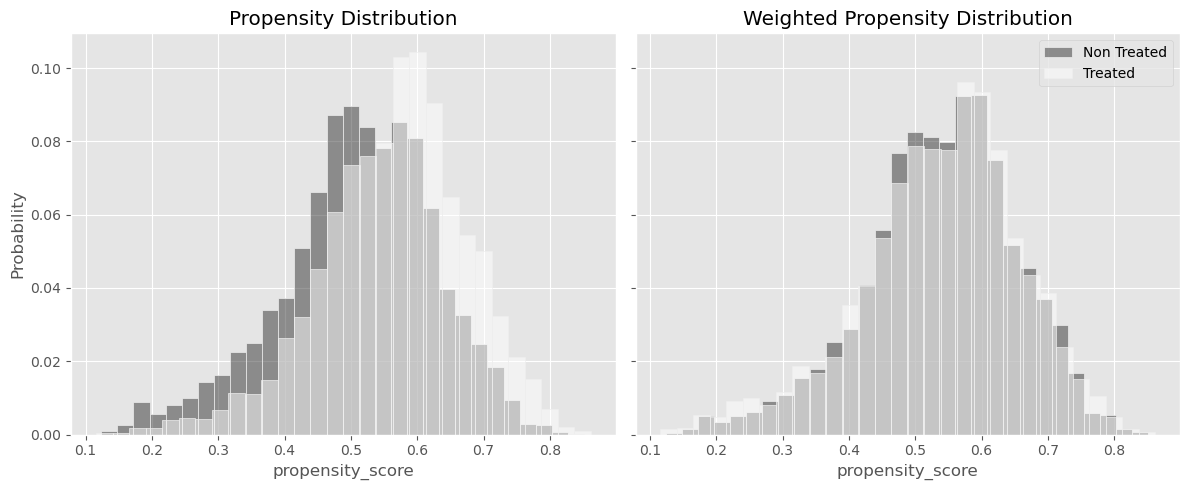

In [69]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5), sharex=True, sharey=True)

sns.histplot(data_ps.query("intervention==0")["propensity_score"], stat="probability",
             label="Not Treated", color="C0", bins=30, ax=ax1, alpha=0.5)
sns.histplot(data_ps.query("intervention==1")["propensity_score"], stat="probability",
             label="Treated", color="C2", alpha=0.5, bins=30, ax=ax1)
ax1.set_title("Propensity Distribution")

sns.histplot(data_ps.query("intervention==0").assign(w=weight_nt_stable),
             x="propensity_score", stat="probability",
             color="C0", weights="w", label="Non Treated", bins=30, ax=ax2,  alpha=0.5)

sns.histplot(data_ps.query("intervention==1").assign(w=weight_t_stable),
             x="propensity_score", stat="probability",
             color="C2", weights="w", label="Treated", bins=30, alpha=0.5, ax=ax2)
ax2.set_title("Weighted Propensity Distribution")
plt.legend()

plt.tight_layout()
plt.show()


<br>

- IPW는 실험군의 결과인 $Y|T=1$을 취하고 $\hat{e}(x)$가 낮으면 가중치를 높이고, $\hat{e}(x)$가 높으면 가중치를 낮추어서 $Y_1 |T=0$이 어떤 형태인지 알아내는 것
    
    마찬가지로 대조군 표본에 $1 / (1-P(T=1))$만큼 재조정함으로써, $Y_0 |T=1$을 파악하려는 시도

<br>

<br>

### 08. 선택편향
- IPW는 교란편향을 이해하고 보정하는 방식에서 성향점수 가중치를 활용하는 것
- 그뿐만 아니라 IPW는 선택 문제 (Selection Issue)를 보정하는 데도 사용


<br>


- 예) 앱에 대한 고객 만족도
    - 1 ~ 5까지의 척도로 제품을 평가
    - 일부 고객은 응답하지 않았으므로, 분석결과가 편향될 수 있다는 문제 가능 (선택편향)
    - 만약 미응답자 대부분이 앱에 불만족한 고객이라면, 설문 결과는 인위적으로 부풀려졌을 가능성

    $\rightarrow$ 고객의 공변량 (나이, 소득 앱 사용량 등)이 주어지면 응답률 $R, P(R=1|X)$를 추정할 수 있음

    $\rightarrow$ 응답자에게 $1 / \hat{P}(R=1)$만큼의 가중치를 부여
        
    $\rightarrow$ 이는 $\hat{P}(r=1)$이 낮은 미응답자와 유사한 응답자에게 높은 가중치를 부여 


<br>

> "응답할 확률이 낮은 사람이 응답했다면, 그 데이터는 응답하지 않은 수많은 비슷한 사람들을 대변하는 매우 귀중한 데이터다. 따라서 가중치를 높게 줘서 데이터의 균형을 맞춘다."

<br>

- **교란편향과 선택편향을 동시에 마주하는 경우, 선택편향과 교란편향에 두 가중치의 곱을 사용 가능**

$$
W = \frac{\hat{P}(T=t)}{\hat{P}(R=1 |X) \hat{P}(T=t|X)}
$$

$$ = \underbrace{\frac{1}{\hat{P}(R=1 |X)}}_{\text{선택 편향 보정}} \times \underbrace{\frac{\hat{P}(T=t)}{\hat{P}(T=t|X)}}_{\text{교란 편향 보정 (안정화)}}$$






<br>

### 09. 편향-분산 트레이드오프
- 처치를를 잘 예측하는 공변량 $X_k$가 있다면, 이 변수는 $e(x)$에 대한 정확한 모델을 제공할 것

    **그러나 해당 변수가 $Y$의 원인이 아니라면, 이는 교란 요인이 아니며, IPW 추정값의 분산만 높일 것** 
    
    - 예) **$T$에 대해 매우 정확한 모델이 존재하며, 이 모델은 모든 실험군에서 매우 높은 $\hat{e}(x)$를, 모든 대조군에서 매우 낮은 $\hat{e}(x)$를 도출**

        **이렇게 하면 $Y_1 |T=0$을 추정할 수 있는 $\hat{e}(x)$가 낮은 실험군이 없고, 반대로 $Y_0|T=1$를 추정할 수 있는 $\hat{e}(x)$가 높은 대조군이 남지 않음**

<br>

- **반면에 처치가 무작위 배정된다면 $\rightarrow$ $\hat{e}(x)$의 예측력은 0이 되어야 함**

    **처치에 대한 예측력은 없지만, 이것이 처치효과를 추정하기에는 가장 바람직한 데이터**

<br>

- IPW에는 편향-분산 트레이드오프가 존재
    - **일반적으로 성향 점수 모델이 더 정확할수록 편향이 작아지지만, $e(x)$에 대해 매우 정확한 모델은 매우 부정확한 효과 추정값을 생성**

    $\rightarrow$ 즉, 편향을 통제할 수 있을 정도로 정밀하게 모델을 만들되, 너무 과도하면 분산 문제가 발생 

- IPW 추정량의 분산을 줄이는 한 가지 방법은 성향점수를 항상 특정 수준 이상으로 유지하는 것
    - 예) 너무 큰 가중치 할당을 피하기 위해 성향점수를 최소 1% 이상으로 설정 (혹은 가중치가 너무 크지 않도록 제한)
    
    $\rightarrow$ 가중치가 제한된 IPW는 더 이상 편향되지 않지만, 분산 감소가 뚜렷하면 평균제곱오차가 낮아질 수 있음

<br>


### 10. 성향점수의 양수성 가정
- 편향-분산 트레이드오프는 두 가지 인과추론 가정인 조건부 독립 (비교란성)과 양수성 관점에서 바라볼 수 있음
    - 예) 더 많은 변수를 추가하여 $e(x)$에 대한 모델을 더 정교하게 만들수록 조건부 독립성 가정을 만족하는 방향으로 나아갈 수 있으나, 동시에 양수성 가정의 타당성이 감소

        대조군에서 멀리 떨어진 낮은 $\hat{e}(x)$ 영역에 처치가 집중되고, 그 반대도 마찬가지이기 때문

        **즉, 모델이 너무 정교해져서 실험군과 대조군을 완벽하게 분리해버리면, 정작 필요한 '비슷한 관측값끼리의 비교' 자체가 불가능**
    
<br>

- IPW 재구성은 재조정할 수 있는 표본이 잇을 때만 가능 
    - 성향점수가 낮은 (대조군이 될 확률이 높은)영역에 처치 받은 표본이 없다면, 해당 영역에서 $Y_1$을 재구성하는 재조정은 불가능  $\rightarrow$ 양수성 가정이 위배
    - 양수성 가정이 완전히 위배되지 않았더라도, 일부 실험 대상의 성향점수가 매우 작거나 크면, IPW는 큰 분산에서 오는 문제가 발생

<br>

- 시뮬레이션
    - 실제 ATE는 1
    - $X$는 $T$ 와 $Y$의 관계를 교란
    - $X$가 클수록 $Y$는 작아지지만, 처치 받을 가능성은 높아짐 $\rightarrow$ 실험군과 대조군 간의 평균 결과를 단순비교하면 하향 편향되고 심지어 음수가 될 수 있음
    

In [71]:
np.random.seed(1)

n = 1000
x = np.random.normal(0, 1, n)
t = np.random.normal(x, 0.5, n) > 0

y0 = -x
y1 = y0 + t  # ate of 1

y = np.random.normal((1-t)*y0 + t*y1, 0.2)

df_no_pos = pd.DataFrame(dict(x=x,t=t.astype(int),y=y))

df_no_pos.head()

,x,t,y
0,1.624345,1,-0.526442
1,-0.611756,0,0.659516
2,-0.528172,0,0.438549
3,-1.072969,0,0.950810
4,0.865408,1,-0.271397


<br>

- 이 데이터에서 성향점수를 추정하면, 일부 실험 대상 ($x$값이 높음)은 성향점수가 거의 1에 가까워져 처치 받을 가능성이 매우 높음

    반대로, 일부 실험 대상 ($x$값이 낮음)은 성향점수가 거의 0에 가까워짐

    $\rightarrow$ **$e(x)$가 거의 0에 가까운 곳에서 대조군 분포의 상당 부분이 모여있지만, 해당 영역을 재구성할 실험군이 없음**

    $\rightarrow$ **데이터의 상당 부분에서 $Y_1 | T=0$의 좋은 추정값을 얻지 못하게 됨**

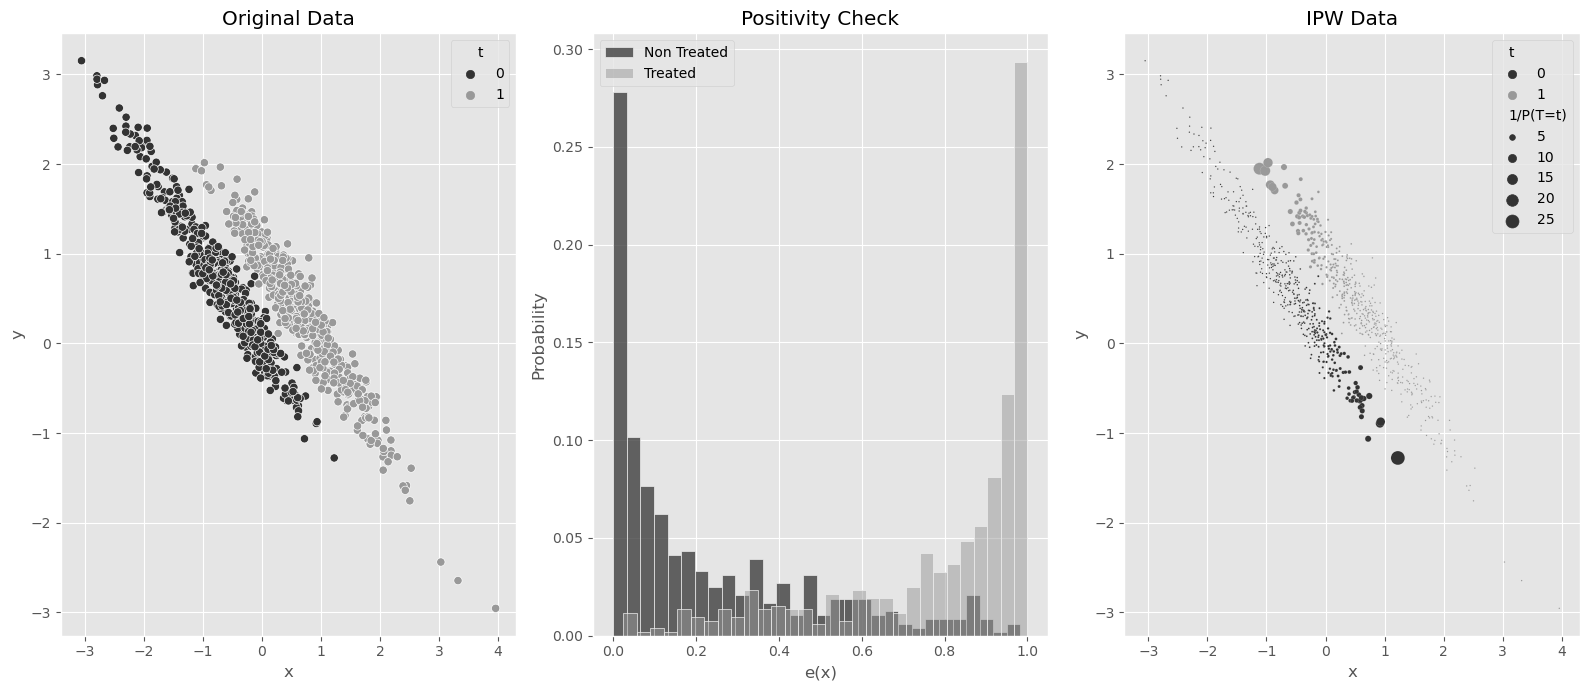

In [72]:
ps_model_sim = smf.logit("""t ~ x""", data=df_no_pos).fit(disp=0)
df_no_pos_ps = df_no_pos.assign(ps=ps_model_sim.predict(df_no_pos))

ps = ps_model_sim.predict(df_no_pos)
w = df_no_pos["t"]*df_no_pos["t"].mean()/ps  + (1-df_no_pos["t"])*((1-df_no_pos["t"].mean())/(1-ps))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16,7))

sns.scatterplot(data=df_no_pos_ps.assign(w=w), x="x", y="y", hue="t", ax=ax1);
ax1.set_title("Original Data")

sns.histplot(df_no_pos_ps.query("t==0")["ps"], stat="probability", label="Non Treated", color="C0", bins=30, ax=ax2)
sns.histplot(df_no_pos_ps.query("t==1")["ps"], stat="probability", label="Treated", color="C1", alpha=0.5, bins=30, ax=ax2)
ax2.set_xlabel("e(x)")
ax2.legend()
ax2.set_title("Positivity Check")

sns.scatterplot(data=df_no_pos_ps.assign(**{"1/P(T=t)":w}), x="x", y="y", hue="t", ax=ax3, size="1/P(T=t)", sizes=(1, 100));
ax3.set_title("IPW Data")

plt.tight_layout()
plt.show()

<br>

#### IPW 추정량과 선형회귀분석
- '큰 분산'과 '양수성 가정 위배'라는 이 두 문제로, IPW 추정량이 데이터에서 ATE를 1로 찾지 못함

In [73]:
est_fn = partial(est_ate_with_ps, ps_formula="x", T="t", Y="y")
print("ATE:",  est_fn(df_no_pos))
print(f"95% C.I.: ", bootstrap(df_no_pos, est_fn))

ATE: 0.5729810455268112
95% C.I.:  [0.36816248 0.76746189]


- 회귀분석은 양수성 가정 위배에 그다지 명확하지 않지만, 실제 데이터가 전혀 없는 영역까지 외삽
    
    선형모델이 조건부 기댓값을 잘 반영한다면, 양수성 가정이 유지되지 않는 영역에서도 ATE를 잘 구할 수 있음

In [75]:
smf.ols("t ~ x + t", data=df_no_pos).fit().params["t"]

1.0000000000000002

<br>

<hr>